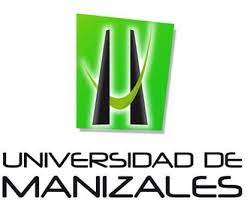
# Maestría en Gestión Estratégica de la Información
# Universidad de Manizales

## Módulo: Probabilidades

#**Análisis Exploratorio de Datos (EDA) -- Geronimo Saldaña Espinal**

#**Python**

Python ha sido uno de los lenguajes de programación más utilizados por la comunidad de científicos de datos, tanto para la preparación de datos como para la implementación de modelos de machine learning y deep learning. Este lenguaje nos permite realizar un análisis exploratorio de datos mediante una de sus librerías, Pandas.

#**Pandas**

Pandas es una librería especializada en el manejo y análisis de estructuras de datos.

Documentación oficial: https://pandas.pydata.org.

Pandas nos permite cargar datos, modelarlo, realizar la preparación, manipulación y análisis de los mismos, para ello nos presenta un concepto fundamental para visualizar las estructuras de datos, los DataFrames. Son estructuras de datos etiquetados bidimensionales, es decir, que contienen filas y columnas.

Pandas es una librería de código abierto de Python, basada en Numpy (librería para manejo de arrays) y Matplotlib (librería para visualización de datos).

**Paso #1:** Cargamos las librerias necesarias: Pandas, Numpy, Matplotlib, Statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

**Paso #2:** Cargamos la base de datos guardada en Google Drive

In [2]:
# Función que nos permite importar el dataset del google drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**Paso #3:** Cargamos el archivo de excel BANCO.XLSX

In [3]:
data = pd.read_excel('/content/drive/MyDrive/Probabilidades/BANCO.xlsx')

Visualizamos la Base de Datos (Dataset)

In [4]:
data

,ID_Cliente,Edad,Nivel_Educativo,Ingresos,Deuda_Ingresos,Deuda_Tarjeta,Otras_Deudas,Impago
0,10012,28,Título de Bachiller,44,17.7,2.99,4.80,No
1,10017,64,Título de Post-grado,116,14.7,5.05,12.00,No
2,10030,40,No completó el bachillerato,61,4.8,1.04,1.89,No
3,10039,30,No completó el bachillerato,27,34.5,1.75,7.56,No
4,10069,25,No completó el bachillerato,30,22.4,0.76,5.96,Sí
...,...,...,...,...,...,...,...,...
1495,453471,34,Superiores iniciados,83,11.0,1.85,7.28,No
1496,453578,37,Título de Bachiller,43,3.6,0.81,0.74,No
1497,453686,25,Título de Post-grado,16,3.2,0.29,0.22,No
1498,453698,34,No completó el bachillerato,41,14.5,1.19,4.75,No


# **Algunos comandos básicos en Python**

Mostramos los primeros 5 registros

In [ ]:
data.head()

,ID_Cliente,Edad,Nivel_Educativo,Ingresos,Deuda_Ingresos,Deuda_Tarjeta,Otras_Deudas,Impago
0,10012,28,Título de Bachiller,44,17.7,2.99,4.80,No
1,10017,64,Título de Post-grado,116,14.7,5.05,12.00,No
2,10030,40,No completó el bachillerato,61,4.8,1.04,1.89,No
3,10039,30,No completó el bachillerato,27,34.5,1.75,7.56,No
4,10069,25,No completó el bachillerato,30,22.4,0.76,5.96,Sí


In [ ]:
data.head(3)

,ID_Cliente,Edad,Nivel_Educativo,Ingresos,Deuda_Ingresos,Deuda_Tarjeta,Otras_Deudas,Impago
0,10012,28,Título de Bachiller,44,17.7,2.99,4.80,No
1,10017,64,Título de Post-grado,116,14.7,5.05,12.00,No
2,10030,40,No completó el bachillerato,61,4.8,1.04,1.89,No


**Número de registros y variables**

In [ ]:
data.shape

(2752, 32)

In [ ]:
print('Numero de Registros y Variables:',data.shape)

Numero de Registros y Variables: (1500, 8)


**Nombre de Variables**

In [ ]:
data.columns

Index(['ID_Cliente', 'Edad', 'Nivel_Educativo', 'Ingresos', 'Deuda_Ingresos',
       'Deuda_Tarjeta', 'Otras_Deudas', 'Impago'],
      dtype='object')

In [ ]:
print('Nombre variables:',data.columns)

Nombre variables: Index(['ID_Cliente', 'Edad', 'Nivel_Educativo', 'Ingresos', 'Deuda_Ingresos',
       'Deuda_Tarjeta', 'Otras_Deudas', 'Impago'],
      dtype='object')


**Información de las variables**

Con el comando data.info(), se obtiene información de cada una de las variables que conforman el set de datos, # que corresponde a un valor entero entre 0 y n-1, que representa cada una de las columna, el nombre de las columnas, el número de elementos no nulos y el tipo de variable que se analiza. Dentro de los tipos de variables se tiene ***int64*** ue representa valores enteros, ***object*** ue representa las variables categoricas, ***float64*** representa valores reales, se pueden encontrar también variables booleanas.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Cliente       1500 non-null   int64  
 1   Edad             1500 non-null   int64  
 2   Nivel_Educativo  1500 non-null   object 
 3   Ingresos         1500 non-null   int64  
 4   Deuda_Ingresos   1500 non-null   float64
 5   Deuda_Tarjeta    1500 non-null   float64
 6   Otras_Deudas     1500 non-null   float64
 7   Impago           1500 non-null   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 93.9+ KB


**Descripción estadística de las variables numéricas**

Con el comando data.describe, podemos obtener las siguientes características de la Base de Datos:

**count:** Determina el número de registros no nulos de la base de datos

**mean:** Determina la media o promedio de cada una de las variables

**std:** Determina la desviación estándar del conjunto de datos

**min** Determina el valor mínimo

**25%:** Indica el valor donde se ubica el Primer Cuartil Q1

**50%:** Indica el valor donde se ubica la mediana Me o Segundo Cuartil Q2

**75%:** Indica el valor donde se ubica el Tercer Cuartil Q3

**max:** Determina el valor máximo

In [ ]:
data.describe()

,ID_Cliente,Edad,Ingresos,Deuda_Ingresos,Deuda_Tarjeta,Otras_Deudas
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,257714.548000,34.174000,59.588667,9.929333,1.934913,3.844327
std,139555.147719,13.142306,67.130160,6.671884,2.973909,5.333425
min,10012.000000,18.000000,12.000000,0.000000,0.000000,0.000000
25%,98638.750000,24.000000,27.000000,4.800000,0.420000,1.107500
50%,315991.500000,31.000000,40.000000,8.500000,0.990000,2.215000
75%,370701.500000,42.000000,64.000000,13.525000,2.200000,4.572500
max,453777.000000,79.000000,1079.000000,40.700000,35.970000,63.470000


**Pregunta:** Para ud como candidato a Magister en Gestión Estratégica de la Información, dada una variable cuantitativo, ¿cuál medida permite analizar mejor dicha variable y porqué?

# **Tablas de Frecuencia**

Una tabla de frecuencias es una tabla que muestra las frecuencias de diferentes categorías. Este tipo de tabla es particularmente útil para comprender la distribución de valores en un conjunto de datos.

In [ ]:
datos = pd.Series ([1, 1, 1, 2, 3, 3, 3, 3, 4, 4, 5])
datos

0     1
1     1
2     1
3     2
4     3
5     3
6     3
7     3
8     4
9     4
10    5
dtype: int64

Vamos a encontrar las frecuencias de cada valor

In [ ]:
datos.value_counts ()

3    4
1    3
4    2
5    1
2    1
dtype: int64

In [ ]:
data.value_counts ('Edad')

Edad
18    71
19    69
23    65
20    63
30    60
26    58
25    56
24    54
28    51
21    49
22    47
33    46
34    45
27    45
29    45
37    37
32    36
39    33
35    33
31    33
36    32
40    32
38    31
41    30
42    29
43    29
46    25
45    23
47    20
44    18
51    17
52    17
53    16
49    15
56    15
48    13
61    12
59    11
62    11
54    10
64    10
50     9
65     9
57     8
58     7
55     7
66     6
63     5
70     5
71     5
68     4
69     4
60     3
72     3
73     3
75     3
67     2
76     2
77     2
79     1
dtype: int64

In [ ]:
data.value_counts('Impago')/1500*100

Impago
No    63.466667
Sí    36.533333
dtype: float64

Veamos ahora en nuestra base de datos, la variable edad

In [ ]:
data.Nivel_Educativo.describe()

count                    1500
unique                      5
top       Título de Bachiller
freq                      527
Name: Nivel_Educativo, dtype: object

In [ ]:
Educación= data.value_counts ('Nivel_Educativo')

In [ ]:
Educación

Nivel_Educativo
Título de Bachiller            527
Superiores iniciados           333
Título Superior                310
No completó el bachillerato    246
Título de Post-grado            84
dtype: int64

# **Grafico de Barras**

<Axes: title={'center': 'Nivel_Educativo'}, xlabel='Nivel_Educativo'>

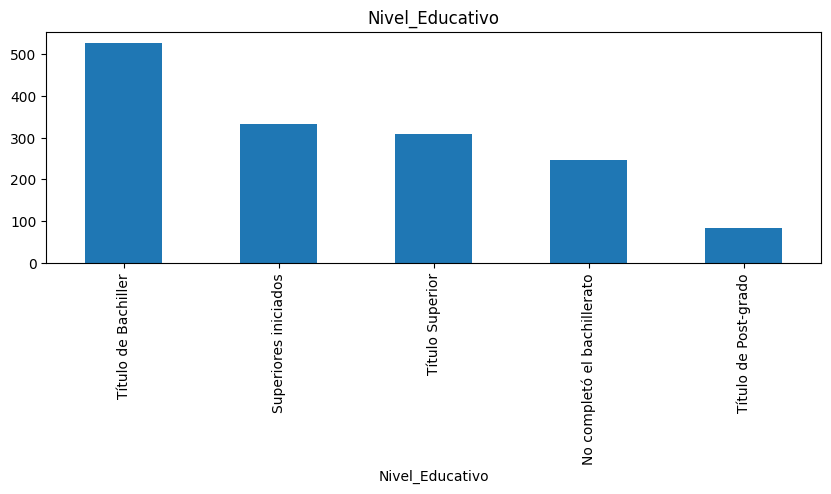

In [7]:
data['Nivel_Educativo'].value_counts().plot(kind='bar', title='Nivel_Educativo',figsize=(10,3))

<Axes: title={'center': 'Impago'}, xlabel='Impago'>

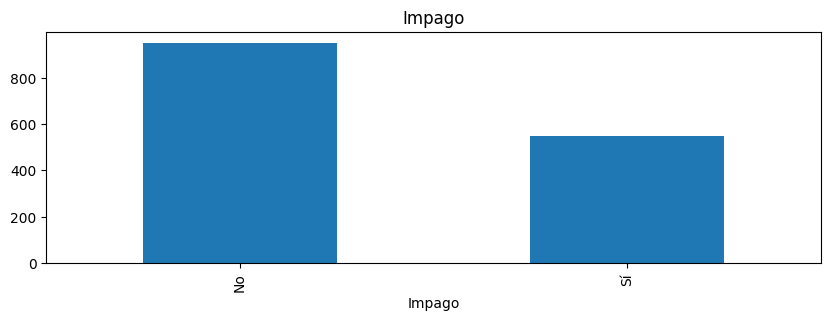

In [9]:
data['Impago'].value_counts().plot(kind='bar', title='Impago',figsize=(10,3))

<Axes: title={'center': 'Nivel_Educativo'}, xlabel='Nivel_Educativo'>

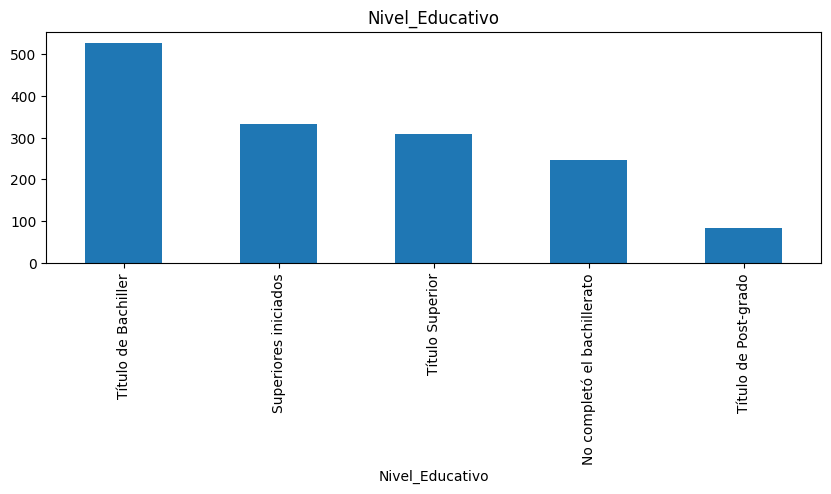

In [11]:
data['Nivel_Educativo'].value_counts().plot(kind='bar', title='Nivel_Educativo',figsize=(10,3))

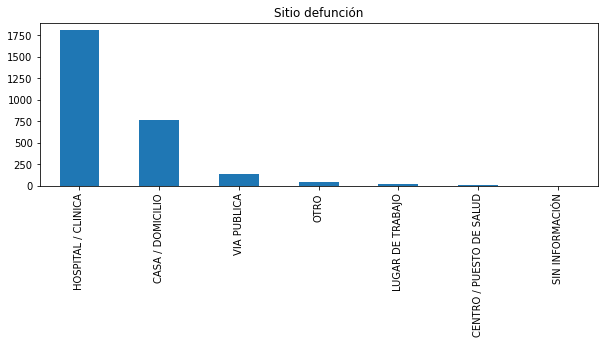

In [ ]:
data['Sitio defunción'].value_counts().plot(kind='bar',title='Sitio defunción',figsize=(10,3))

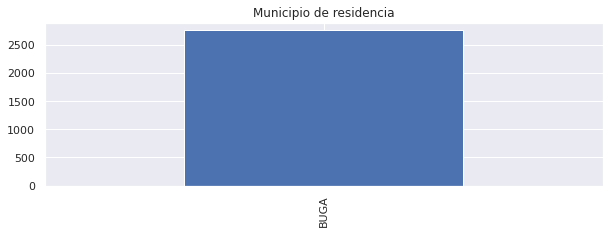

In [ ]:
data['Municipio de residencia'].value_counts().plot(kind='bar',title='Municipio de residencia',figsize=(10,3))

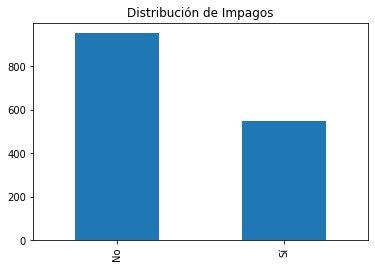

In [ ]:
data['Impago'].value_counts().plot(kind='bar', title='Distribución de Impagos')

# **Gráfico de Torta**

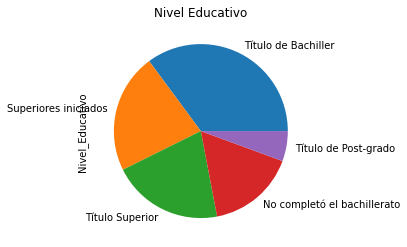

In [ ]:
data['Nivel_Educativo'].value_counts().plot(kind='pie', title='Nivel Educativo')

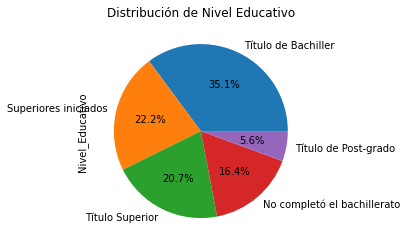

In [ ]:
data['Nivel_Educativo'].value_counts().plot(kind='pie',autopct='%.1f%%', title='Distribución de Nivel Educativo')

In [ ]:
data['Probable manera de muerte'].value_counts().plot(kind='pie',autopct='%.1f%%', title='Probable manera de muerte')

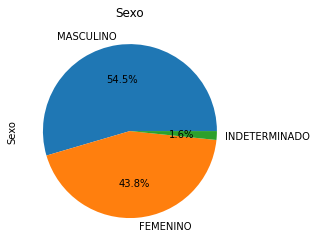

In [ ]:
data['Sexo'].value_counts().plot(kind='pie',autopct='%.1f%%', title='Sexo')

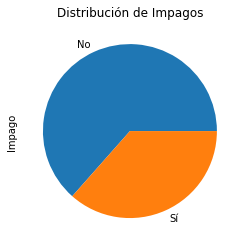

In [ ]:
data['Impago'].value_counts().plot(kind='pie', title='Distribución de Impagos')

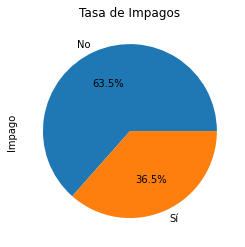

In [ ]:
data['Impago'].value_counts().plot(kind='pie',autopct='%.1f%%', title='Tasa de Impagos')

# **Gráficos de Barras Apilados**

Queremos determinar el nivel Educativo de las personas que presentan Impagos

In [14]:
Educ_Impagos=data.groupby(['Nivel_Educativo','Impago']).size()
Educ_Impagos

Nivel_Educativo              Impago
No completó el bachillerato  No        182
                             Sí         64
Superiores iniciados         No        213
                             Sí        120
Título Superior              No        170
                             Sí        140
Título de Bachiller          No        330
                             Sí        197
Título de Post-grado         No         57
                             Sí         27
dtype: int64

Convertimos el Nivel Educativo en una columna para manejar la tabla como un dataframe

In [15]:
Educ_Impagos = Educ_Impagos.reset_index()
Educ_Impagos

,Nivel_Educativo,Impago,0
0,No completó el bachillerato,No,182
1,No completó el bachillerato,Sí,64
2,Superiores iniciados,No,213
3,Superiores iniciados,Sí,120
4,Título Superior,No,170
5,Título Superior,Sí,140
6,Título de Bachiller,No,330
7,Título de Bachiller,Sí,197
8,Título de Post-grado,No,57
9,Título de Post-grado,Sí,27


Creamos una tabla pivote para tener solamente dos filas y 5 columnas

In [17]:
Educ_Impagos =pd.pivot_table(Educ_Impagos,columns='Impago', index='Nivel_Educativo',values=0)
Educ_Impagos

Impago,No,Sí
Nivel_Educativo,,
No completó el bachillerato,182.0,64.0
Superiores iniciados,213.0,120.0
Título Superior,170.0,140.0
Título de Bachiller,330.0,197.0
Título de Post-grado,57.0,27.0


<Axes: title={'center': 'Nivel Educativo por impagos'}, xlabel='Nivel_Educativo'>

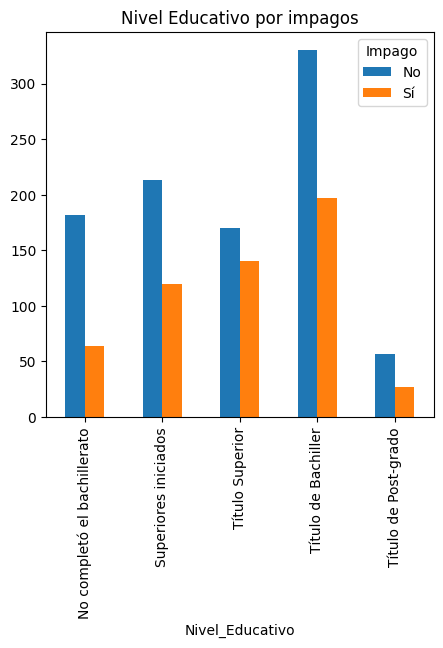

In [18]:
Educ_Impagos.plot(kind='bar',title='Nivel Educativo por impagos',figsize=(5,5))

Creamos el gráfico de Barras

<Axes: title={'center': 'Nivel Educativo por impagos'}, xlabel='Nivel_Educativo'>

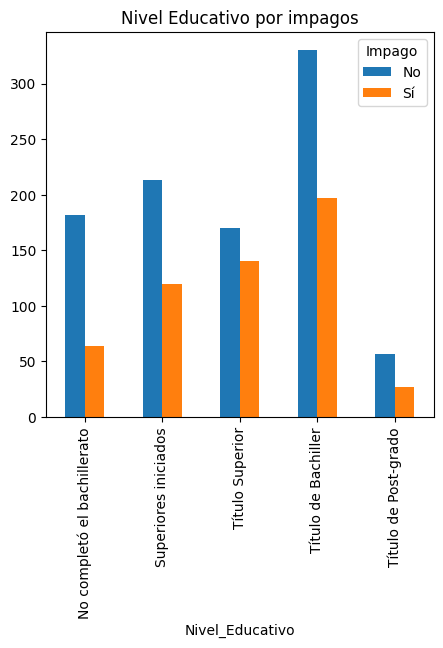

In [19]:
Educ_Impagos.plot(kind='bar', title= 'Nivel Educativo por impagos',figsize=(5,5))

# **Histogramas**

(array([418., 315., 225., 192., 128.,  84.,  51.,  53.,  23.,  11.]),
 array([18. , 24.1, 30.2, 36.3, 42.4, 48.5, 54.6, 60.7, 66.8, 72.9, 79. ]),
 <BarContainer object of 10 artists>)

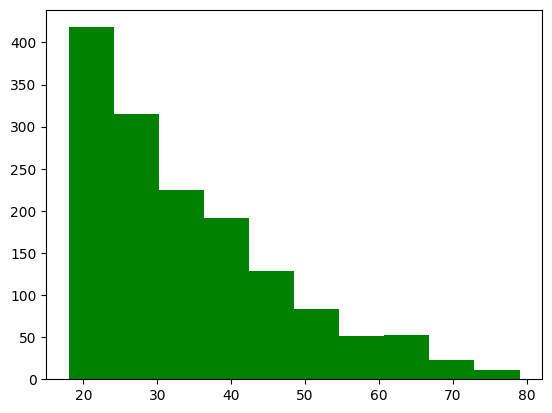

In [20]:
plt.hist(data['Edad'],10, color= 'green', ec='black')

/tmp/ipython-input-108446110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data['Edad'], palette = 'ocean')


<Axes: ylabel='count'>

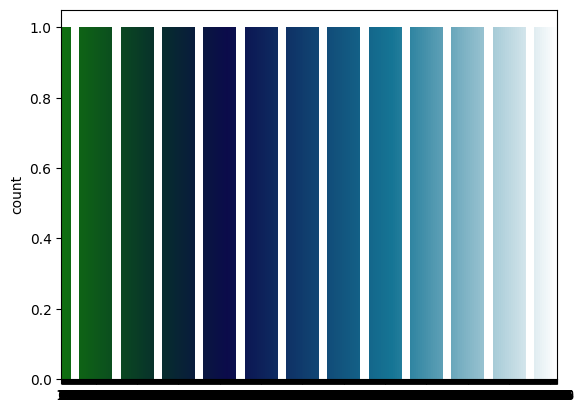

In [7]:
import seaborn as sns
sns.countplot(data['Edad'], palette = 'ocean')

# **Gráficos de Caja y Bigote (Boxplot)**

<Axes: ylabel='Edad'>

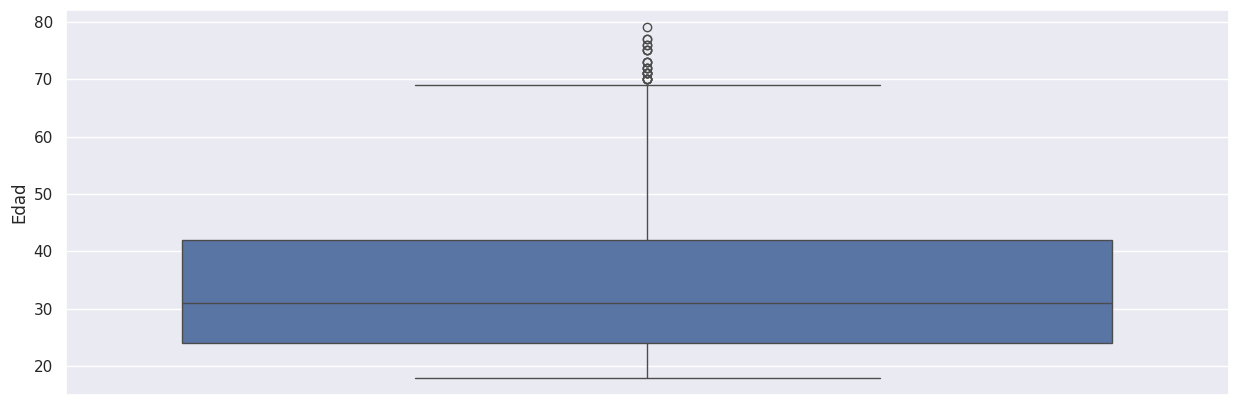

In [9]:
import seaborn as sb
sb.boxplot(data['Edad'])

<Axes: xlabel='Impago', ylabel='Edad'>

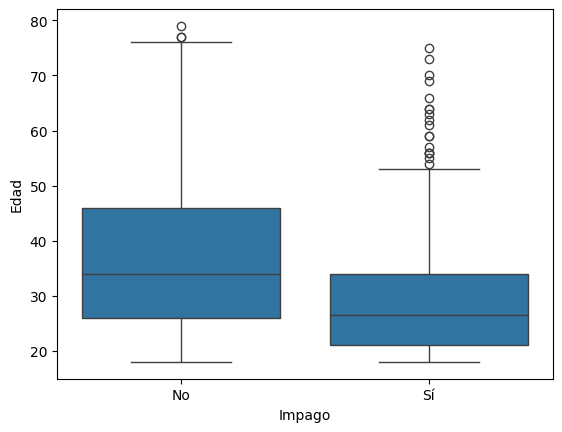

In [24]:
sb.boxplot(x= data['Impago'], y=data['Edad'])

<Axes: xlabel='Nivel_Educativo', ylabel='Edad'>

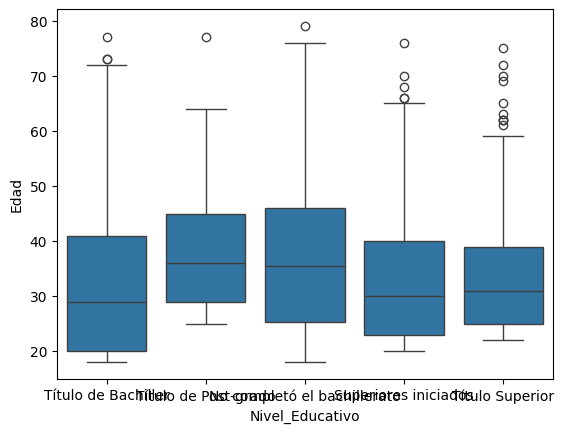

In [26]:
sb.boxplot(x= data['Nivel_Educativo'], y=data['Edad'])

<Axes: xlabel='Nivel_Educativo', ylabel='Edad'>

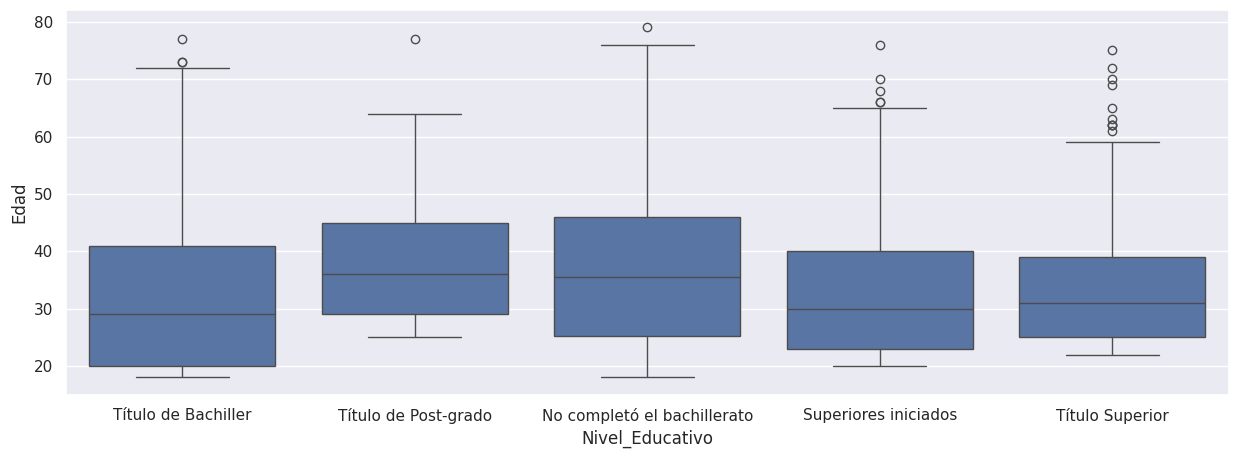

In [10]:
sns.set(rc = {'figure.figsize':(15,5)})
sb.boxplot(x= data['Nivel_Educativo'], y=data['Edad'])

/tmp/ipython-input-3998175095.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data['Ingresos'], palette='Set1')


<Axes: ylabel='Ingresos'>

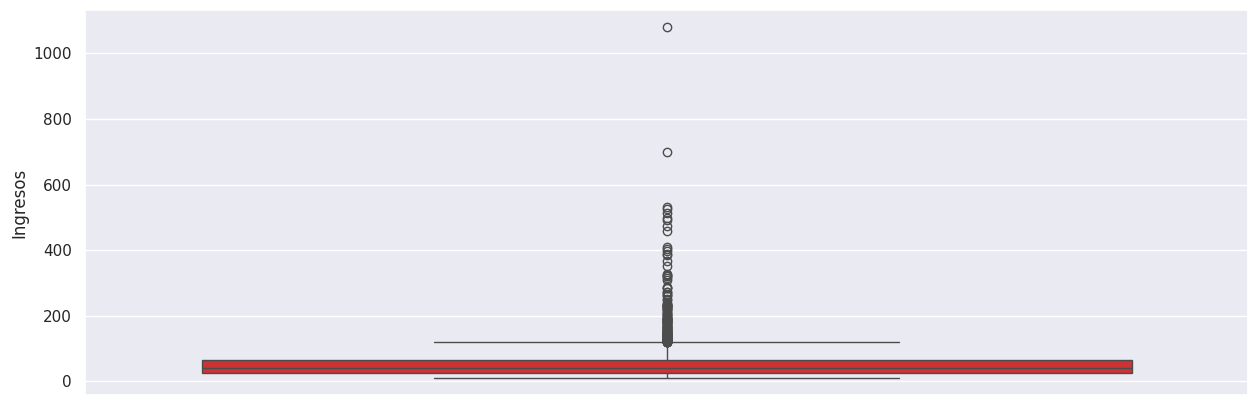

In [11]:
sb.boxplot(data['Ingresos'], palette='Set1')

In [12]:
stats.mode(data['Edad'])

ModeResult(mode=np.int64(18), count=np.int64(71))

# **Gráficos de Dispersión**

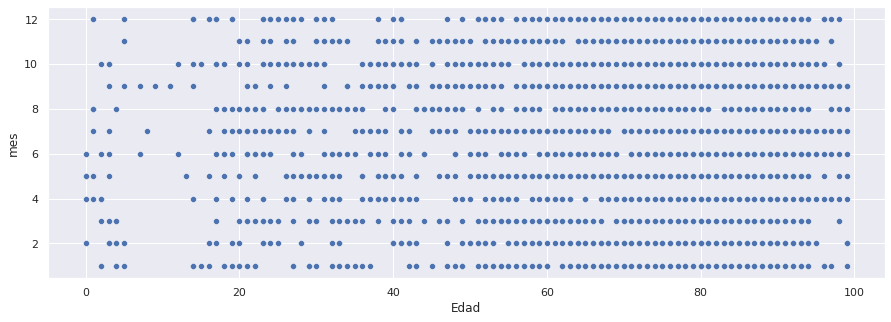

In [ ]:
sns.scatterplot(data=data, x= 'Edad', y='mes')

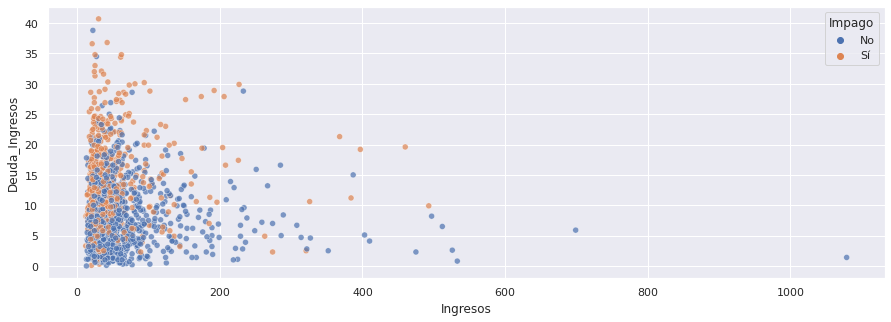

In [ ]:
sns.scatterplot(data=data, x= 'Ingresos', y='Deuda_Ingresos',hue='Impago',alpha=0.7)

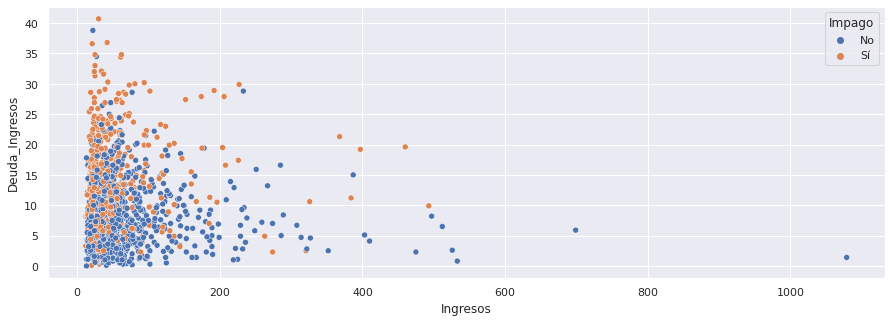

In [ ]:
sns.scatterplot(data=data, x= 'Ingresos', y='Deuda_Ingresos', hue='Impago')

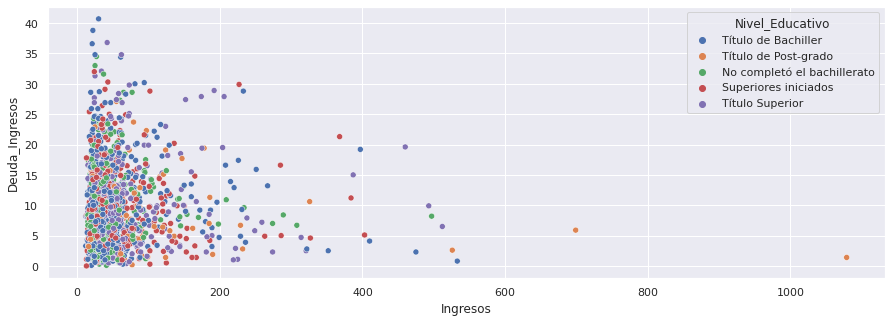

In [ ]:
sns.scatterplot(data=data, x= 'Ingresos', y='Deuda_Ingresos', hue='Nivel_Educativo')

# **Matriz de Correlación**

In [ ]:
data2= data[['Edad', 'Ingresos', 'Deuda_Ingresos', 'Deuda_Tarjeta','Otras_Deudas']]
data2.head()

,Edad,Ingresos,Deuda_Ingresos,Deuda_Tarjeta,Otras_Deudas
0,28,44,17.7,2.99,4.80
1,64,116,14.7,5.05,12.00
2,40,61,4.8,1.04,1.89
3,30,27,34.5,1.75,7.56
4,25,30,22.4,0.76,5.96


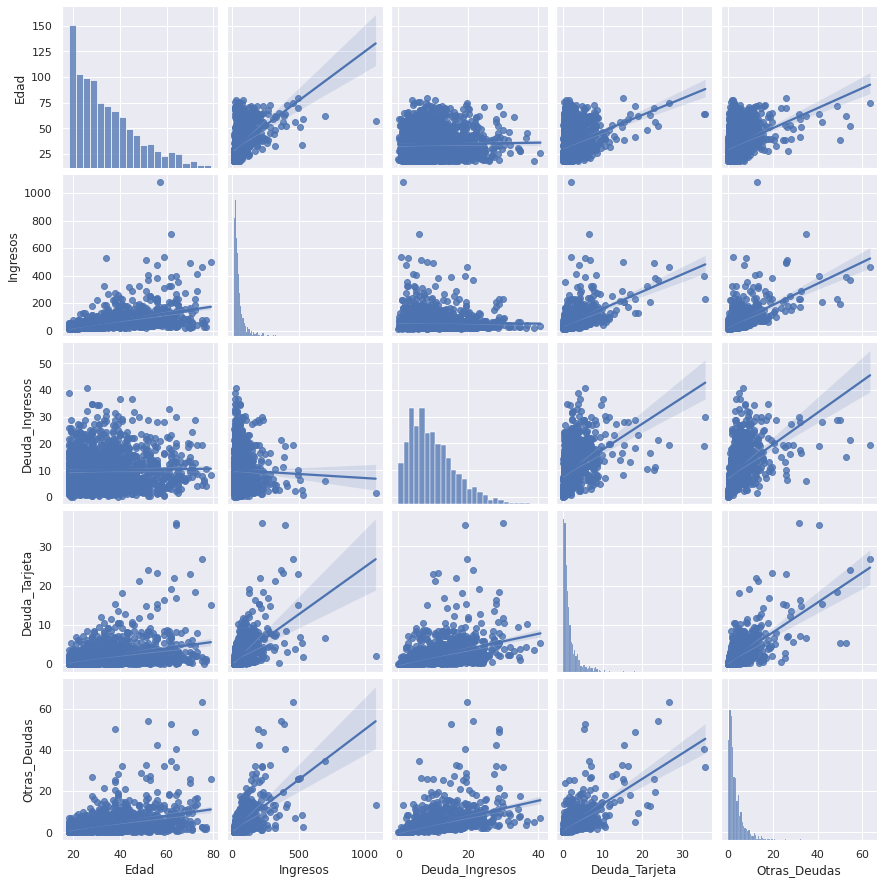

In [ ]:
sns.pairplot(data2, kind='reg')

In [ ]:
cor= data2.corr()
cor

,Edad,Ingresos,Deuda_Ingresos,Deuda_Tarjeta,Otras_Deudas
Edad,1.000000,0.493960,0.027182,0.359119,0.396620
Ingresos,0.493960,1.000000,-0.030726,0.548637,0.618898
Deuda_Ingresos,0.027182,-0.030726,1.000000,0.429713,0.476866
Deuda_Tarjeta,0.359119,0.548637,0.429713,1.000000,0.681259
Otras_Deudas,0.396620,0.618898,0.476866,0.681259,1.000000


Creamos un mapa de calor con las correlaciones

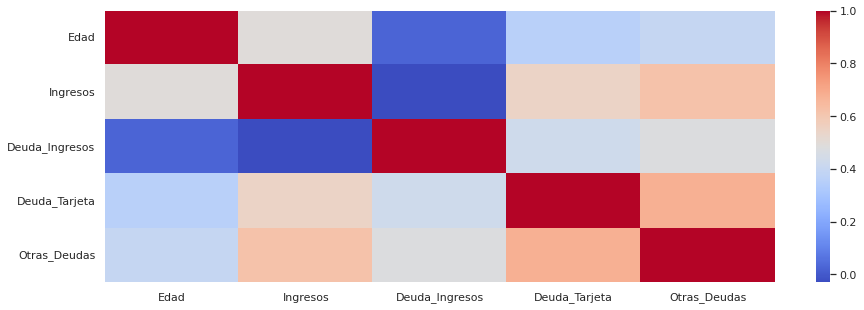

In [ ]:
sns.heatmap(cor, xticklabels=cor.columns, yticklabels=cor.columns, cmap= 'coolwarm')

In [ ]:
pip install pingouin

In [ ]:
import pingouin as pg
cor2 = pg.pairwise_corr(data2, method='pearson')
cor2.sort_values(by=['p-unc'])[['X','Y', 'n', 'r', 'p-unc']]

,X,Y,n,r,p-unc
9,Deuda_Tarjeta,Otras_Deudas,1500,0.681259,3.593445e-205
6,Ingresos,Otras_Deudas,1500,0.618898,2.675987e-159
5,Ingresos,Deuda_Tarjeta,1500,0.548637,1.219485e-118
0,Edad,Ingresos,1500,0.493960,4.302455e-93
8,Deuda_Ingresos,Otras_Deudas,1500,0.476866,5.155668e-86
7,Deuda_Ingresos,Deuda_Tarjeta,1500,0.429713,1.883446e-68
3,Edad,Otras_Deudas,1500,0.396620,1.097705e-57
2,Edad,Deuda_Tarjeta,1500,0.359119,6.969174e-47
4,Ingresos,Deuda_Ingresos,1500,-0.030726,2.343141e-01
1,Edad,Deuda_Ingresos,1500,0.027182,2.927683e-01


In [ ]:
cor2

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
0,Edad,Ingresos,pearson,two-sided,1500,0.493960,"[0.45, 0.53]",4.302455e-93,2.369e+89,1.000000
1,Edad,Deuda_Ingresos,pearson,two-sided,1500,0.027182,"[-0.02, 0.08]",2.927683e-01,0.056,0.183302
2,Edad,Deuda_Tarjeta,pearson,two-sided,1500,0.359119,"[0.31, 0.4]",6.969174e-47,2.312e+43,1.000000
3,Edad,Otras_Deudas,pearson,two-sided,1500,0.396620,"[0.35, 0.44]",1.097705e-57,1.287e+54,1.000000
4,Ingresos,Deuda_Ingresos,pearson,two-sided,1500,-0.030726,"[-0.08, 0.02]",2.343141e-01,0.066,0.221335
5,Ingresos,Deuda_Tarjeta,pearson,two-sided,1500,0.548637,"[0.51, 0.58]",1.219485e-118,6.963e+114,1.000000
6,Ingresos,Otras_Deudas,pearson,two-sided,1500,0.618898,"[0.59, 0.65]",2.675987e-159,2.485e+155,1.000000
7,Deuda_Ingresos,Deuda_Tarjeta,pearson,two-sided,1500,0.429713,"[0.39, 0.47]",1.883446e-68,6.702e+64,1.000000
8,Deuda_Ingresos,Otras_Deudas,pearson,two-sided,1500,0.476866,"[0.44, 0.52]",5.155668e-86,2.092e+82,1.000000
9,Deuda_Tarjeta,Otras_Deudas,pearson,two-sided,1500,0.681259,"[0.65, 0.71]",3.593445e-205,1.461e+201,1.000000


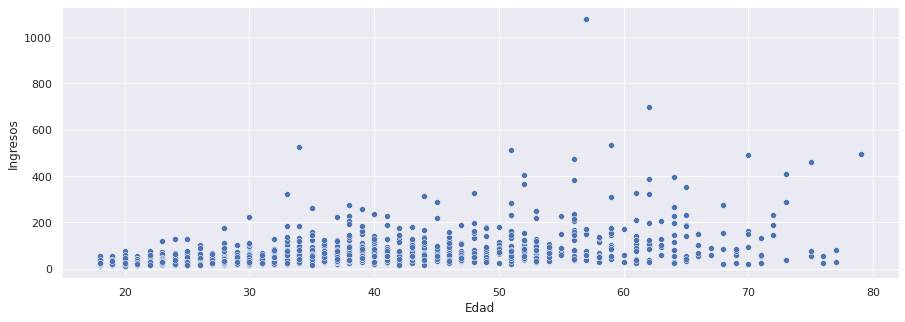

In [ ]:
sns.scatterplot(data=data, x= 'Edad', y='Ingresos')

In [ ]:
cor= data2[['Edad','Ingresos']].corr()
cor

,Edad,Ingresos
Edad,1.00000,0.49396
Ingresos,0.49396,1.00000
